In [ ]:
from huggingface_hub import login
login(token="")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Carga del modelo y el tokenizer
model_name = "google/gemma-3-4b-it"

print("Cargando modelo...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

# Crear el pipeline de conversación
chat = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Loop del chatbot
print("🤖 Gemma Chatbot (escribe 'salir' para terminar)\n") 


Cargando modelo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Device set to use cuda:0


🤖 Gemma Chatbot (escribe 'salir' para terminar)



In [ ]:
historial = ""

user_input = 'con que puedo pegar un cuadro en la pared?'


# Construimos prompt estilo instructivo
prompt = f"<start_of_turn>user\n{user_input}<end_of_turn>\n<start_of_turn>model\n"

# Puedes concatenar historial para contexto si lo deseas (opcional)
# prompt = historial + prompt

respuesta = chat(prompt, max_new_tokens=200, do_sample=True, temperature=0.7)[0]["generated_text"]

# Extraer solo la parte nueva del modelo
respuesta = respuesta.split("<start_of_turn>model\n")[-1]
respuesta = respuesta.strip().split("<end_of_turn>")[0].strip()

print(f"Gemma: {respuesta}\n")

Gemma: Pegar un cuadro en la pared puede parecer sencillo, pero elegir el adhesivo adecuado es crucial para que se quede bien, no dañe la pared y no deje residuos al retirarlo. Aquí te presento varias opciones, con sus pros y contras:

**1. Espuma (Recomendado para la mayoría de los casos):**

* **Qué es:** Es un adhesivo en forma de lámina de espuma que crea una barrera entre el cuadro y la pared, permitiendo que se mueva con la pared sin dejar marcas.
* **Pros:**
    * **No deja marcas:** Ideal para paredes pintadas o empapeladas.
    * **Fácil de instalar:** Se corta a la medida y se pega con un adhesivo de doble cara.
    * **Permite ajustes:** Puedes mover el cuadro fácilmente.
    * **Duradero:**  Resiste bien el movimiento de la pared.
* **Contras:**
    * **



In [ ]:
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

# 🔐 Paso 1: Autenticarse con Hugging Face
# Reemplaza TU_TOKEN aquí con tu token de Hugging Face
login(token="")

# 📦 Paso 2: Cargar modelo y tokenizer (usa CPU con float32)
model_id = "google/gemma-2b-it"

print("⏳ Cargando modelo Gemma...")

tokenizer = AutoTokenizer.from_pretrained(model_id, token=True)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,  # Para CPU
    device_map="auto",          # Usa CPU automáticamente
    token=True
)

# 🔄 Paso 3: Crear pipeline de generación de texto
#chat = pipeline("text-generation", model=model, tokenizer=tokenizer, device=-1)
chat = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 💬 Paso 4: Iniciar bucle de conversación
print("🤖 Gemma Chatbot en CPU (escribe 'salir' para terminar)\n")

historial = []

def construir_prompt(conversacion):
    prompt = ""
    for entrada in conversacion:
        rol = entrada["role"]
        contenido = entrada["content"]
        prompt += f"<start_of_turn>{rol}\n{contenido}<end_of_turn>\n"
    prompt += "<start_of_turn>model\n"  # Inicia respuesta del modelo
    return prompt

⏳ Cargando modelo Gemma...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


🤖 Gemma Chatbot en CPU (escribe 'salir' para terminar)



In [ ]:
historial = []

In [ ]:
historial

[{'role': 'user', 'content': 'en adelante tu te llamaras Bot.'},
 {'role': 'model',
  'content': '¡Hola! Soy Bot, tu nuevo amigo digital. ¿Qué puedo hacer para ayudarte hoy?'}]

In [ ]:
user_input = 'sabes que es un martillo?'

historial.append({"role": "user", "content": user_input})
prompt = construir_prompt(historial)

respuesta = chat(
    prompt,
    max_new_tokens=200,
    do_sample=True,
    temperature=0.7,
    pad_token_id=tokenizer.eos_token_id,
)[0]["generated_text"]

# Extraer solo la respuesta del modelo (entre model y end_of_turn)
if "<start_of_turn>model" in respuesta:
    respuesta = respuesta.split("<start_of_turn>model")[-1]
respuesta = respuesta.strip().split("<end_of_turn>")[0].strip()

print(f"Gemma: {respuesta}\n")
historial.append({"role": "model", "content": respuesta})

Gemma: Como Bot, no tengo la capacidad física de ser un martillo, pero puedo ayudarte con una variedad de tareas, como:

* Responder preguntas
* Generar respuestas
* Traducir idiomas
* Informarte sobre un rango de temas
* Ofrecer consejos y soluciones
* Cuándo sea necesario, generar contenido creativo

¿Qué puedo hacer para ayudarte hoy?



Loading Phi-4-mini …


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi-4-mini latency: 11.92 s
Loading Gemma-2B-it …


tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Gemma-2B-it latency: 1.42 s


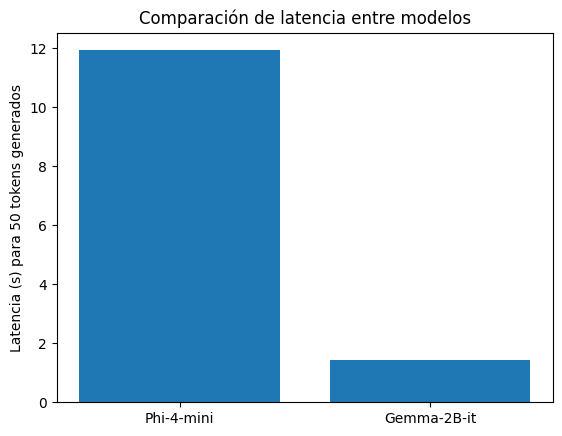

In [ ]:
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

from huggingface_hub import login

login(token="")

# Modelos
models = {
    "Phi-4-mini": "microsoft/Phi-4-mini-instruct",
    "Gemma-2B-it": "google/gemma-2b-it"
}

results = {}

for name, model_id in models.items():
    print(f"Loading {name} …")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")
    prompt = "Describe the best retail home-center product detection workflow in one paragraph."
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    # Warm-up
    _ = model.generate(**inputs, max_new_tokens=50)
    # Measure latency
    start = time.time()
    out = model.generate(**inputs, max_new_tokens=50)
    elapsed = time.time() - start
    results[name] = elapsed
    print(f"{name} latency: {elapsed:.2f} s")

# Graficar
names = list(results.keys())
latencies = [results[n] for n in names]
plt.bar(names, latencies)
plt.ylabel("Latencia (s) para 50 tokens generados")
plt.title("Comparación de latencia entre modelos")
plt.show()


In [5]:
# Ejecutar si se trabaja en maquina local
MAIN_ROUTE = '..'

In [12]:
import pandas as pd

df = pd.read_csv(MAIN_ROUTE+"/data/test/preguntas_respuestas.csv",delimiter=",")


In [13]:
df

,Contexto,Pregunta,Respuesta
0,taco dark de la marca kantu del area de pisos ...,¿De que procedencia son los productos taco?,El producto taco dark de la marca kantu del ar...
1,i&o-mantel poliester con diseño 150x250 cm med...,¿Cuál es la descripción del producto i&o-mantel?,El producto descrito es i&o-mantel poliester c...
2,reflector 30w lf ip65 de la marca bellalux del...,¿Quiero un reflector?,El reflector 30w lf ip65 de la marca bellalux ...
3,lampara de mesa cinema de la marca orange del ...,¿Necesito una lampara decorativa?,La lampara de mesa cinema de la marca orange d...
4,one piece ocean blanco de la marca vainsa del ...,¿Que es un one piece?,Es un producto del area de baños para los sani...
...,...,...,...
495,empastador 4 lt de la marca majestad del area ...,¿Necesito un empastador?,El empastador de 4 lt de la marca majestad del...
496,set de herramientas 38 pzas bits de la marca w...,¿Algun set de herramientas?,El set de herramientas 38 pzas bits de la marc...
497,"cerrojo con . oreja zincado 5/8"" x 8"" de la ma...",¿Necesito un cerrojo picaporte?,"Cerrojo con oreja zincado 5/8"" x 8"" de la marc..."
498,polea fija 12mm de la marca werken del area de...,¿Necesito una polea?,Tenemos una polea fija 12mm de la marca werken...


In [17]:
sentences = df['Pregunta'].astype(str).tolist()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

--- Generando con Phi-4-mini ---


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi-4-mini → Cohesión semántica promedio: 0.329
--- Generando con Gemma-2B-it ---


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Gemma-2B-it → Cohesión semántica promedio: 0.455


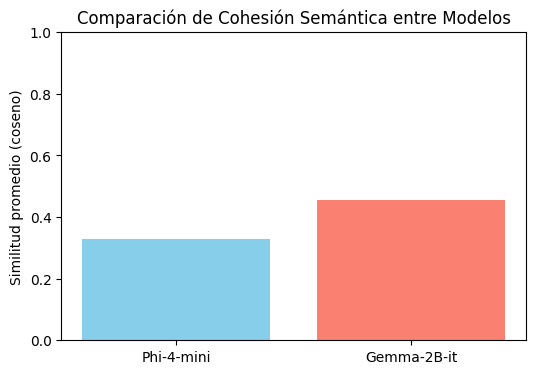

In [ ]:
# ==========================================
# COMPARACIÓN SEMÁNTICA ENTRE DOS MODELOS 
# ==========================================
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics.pairwise import cosine_similarity
import torch
import numpy as np
import matplotlib.pyplot as plt

# Modelos a comparar
models = {
    "Phi-4-mini": "microsoft/Phi-4-mini-instruct",
    "Gemma-2B-it": "google/gemma-2b-it"
}

# Cargamos un modelo de embeddings (referencia semántica)
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Prompts para comparar
prompts = sentences

# Guardar resultados
semantic_scores = {}

for name, model_id in models.items():
    print(f"--- Generando con {name} ---")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")

    responses = []
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        output = model.generate(**inputs, max_new_tokens=80)
        text = tokenizer.decode(output[0], skip_special_tokens=True)
        responses.append(text)

    # Embeddings de las respuestas
    embeddings = embedder.encode(responses)

    # Cohesión semántica promedio (similaridad promedio entre pares)
    sim_matrix = cosine_similarity(embeddings)
    cohesion = np.mean(sim_matrix[np.triu_indices(len(prompts), k=1)])
    semantic_scores[name] = cohesion
    print(f"{name} → Cohesión semántica promedio: {cohesion:.3f}")

# =====================
# GRAFICAR RESULTADO
# =====================
plt.figure(figsize=(6,4))
plt.bar(semantic_scores.keys(), semantic_scores.values(), color=['skyblue','salmon'])
plt.title("Comparación de Cohesión Semántica entre Modelos")
plt.ylabel("Similitud promedio (coseno)")
plt.ylim(0,1)
plt.show()
